# Parte 2: Auditoria do Modelo em Produção

## Desempenho com Incerteza e Análise de Falhas

**Objetivo**: Avaliar o desempenho global do modelo A com rigor estatístico, e investigar onde e por que o modelo falha, identificando padrões nos erros que impactam o encaminhamento dos chamados.

## Setup

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap, kendalltau

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.metrics import balanced_accuracy_score


DADOS_PATH = Path('../dados/chamados_com_predicoes.csv')
FIGURES_PATH = Path('../results/figures/')

In [2]:
cat_map = {
    'iluminacao_publica': 'Iluminação Pública',
    'buraco_via': 'Buraco em Via',
    'coleta_lixo': 'Coleta de Lixo',
    'esgoto_vazamento': 'Vazamento de Esgoto',
    'poda_arvore': 'Poda de Árvore',
    'estacionamento_irregular': 'Estacionamento Irregular',
    'barulho_perturbacao': 'Barulho / Perturbação',
    'sinalizacao': 'Sinalização'
}

## 2. Desempenho com Incerteza

In [3]:
df = pd.read_csv(DADOS_PATH, encoding='utf-8')

y_true = df['categoria_real']
y_pred = df['pred_modelo_a']
classes = sorted(df['categoria_real'].unique())

In [4]:
RANDOM_STATE = 42
N_BOOTSTRAP = 1000

def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro', zero_division=0)

def weighted_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='weighted', zero_division=0)

metrics_global = [
    ('Acurácia', accuracy_score),
    ('Acurácia Balanceada', balanced_accuracy_score),
    ('F1 Macro', macro_f1),
    ('F1 Weighted', weighted_f1)
]

results_global = []
bootstrap_distributions = {}

for name, fn in metrics_global:
    observed = fn(y_true, y_pred)
    res = bootstrap(
        data=(y_true, y_pred),
        statistic=lambda yt, yp: fn(yt, yp),
        n_resamples=N_BOOTSTRAP,
        confidence_level=0.95,
        paired=True,
        method='percentile',
        random_state=RANDOM_STATE
    )

    results_global.append({
        'Métrica': name,
        'Valor observado': observed,
        'IC 95% - inferior': res.confidence_interval.low,
        'IC 95% - superior': res.confidence_interval.high,
        'IC 95%': (
            f'[{res.confidence_interval.low:.3f}, '
            f'{res.confidence_interval.high:.3f}]'
        )
    })

    bootstrap_distributions[name] = res.bootstrap_distribution

metrics_global_df = pd.DataFrame(results_global)

metrics_global_df[
    ['Métrica', 'Valor observado', 'IC 95%']
].style.format({'Valor observado': '{:.3f}'})


,Métrica,Valor observado,IC 95%
0,Acurácia,0.773,"[0.761, 0.784]"
1,Acurácia Balanceada,0.771,"[0.758, 0.784]"
2,F1 Macro,0.770,"[0.758, 0.783]"
3,F1 Weighted,0.773,"[0.761, 0.784]"


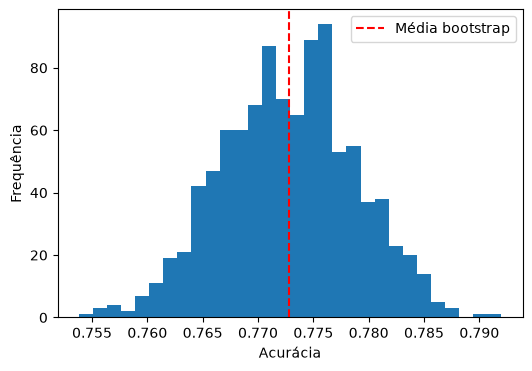

In [5]:
values = bootstrap_distributions["Acurácia"]

plt.figure(figsize=(6,4))
plt.hist(values, bins=30)
plt.axvline(values.mean(), color="red", linestyle="--", label="Média bootstrap")
plt.legend()
plt.xlabel("Acurácia")
plt.ylabel("Frequência")
plt.show()

#### Avaliação

Como o problema é de classificação multiclasse e as categorias não têm exatamente o mesmo volume, a avaliação não dependeu apenas da acurácia global.

A acurácia foi útil para medir o percentual geral de encaminhamentos corretos, mas como poderia mascarar problemas em categorias menos frequentes ou mais difíceis, então também avaliamos métricas que dão maior visibilidade ao desempenho por classe:

- **Balanced Accuracy**: calcula a média do recall entre as categorias, reduzindo o efeito do desbalanceamento.
- **F1 Macro**: calcula a média simples do F1 por categoria, tratando todas as classes com o mesmo peso.
- **F1 Weighted**: calcula o F1 ponderado pelo volume de chamados de cada categoria, refletindo melhor o impacto agregado na operação.

Dessa forma conseguimos avaliar tanto o desempenho geral como a consistência pelas diferentes categorias.

#### Cálculo do Intevalo de Confiança

Para quantificar a incerteza das métricas, foram estimados intervalos de confiança de 95% por bootstrap não paramétrico, com 1.000 reamostragens. O bootstrap foi escolhido, pois a análise busca estimar o quanto métricas como precision, recall, F1-score e balanced accuracy poderiam variar se uma nova amostra semelhante de chamados fosse observada, e permite aproximar empiricamente a distribuição amostral dessas métricas sem exigir hipóteses paramétricas sobre seus comportamentos estatísticos.

Métodos mais refinados, como o bootstrap BCa, poderiam corrigir possíveis vieses e assimetrias nos intervalos de confiança, porém não foram priorizados dado que as distribuições bootstrap das métricas por categoria, mostraram-se suficientemente estáveis e aproximadamente simétricas.

#### Desempenho

O Modelo A apresentou um desempenho global razoável, com acurácia de 77,3% (IC 95%: [0,761; 0,784]), que em média, aproximadamente três em cada quatro chamados são encaminhados para a categoria correta. No entanto, esse resultado também implica um volume operacional relevante de erros: 1.136 dos 5.000 chamados avaliados (22,7%) foram classificados incorretamente.

Como a base possui categorias com volumes diferentes, a acurácia isolada não é suficiente para avaliar a qualidade do modelo. Então avaliando as outras métricas verificamos uma proximidade o que sugere que o desempenho do modelo não está excessivamente concentrado nas categorias mais frequentes, ou seja, não há indícios que o modelo esteja obtendo uma boa acurácia apenas porque classifica bem as categorias mais comuns.

## 3. Onde o Modelo Falha? 

### 3.1 Matriz de Confusão

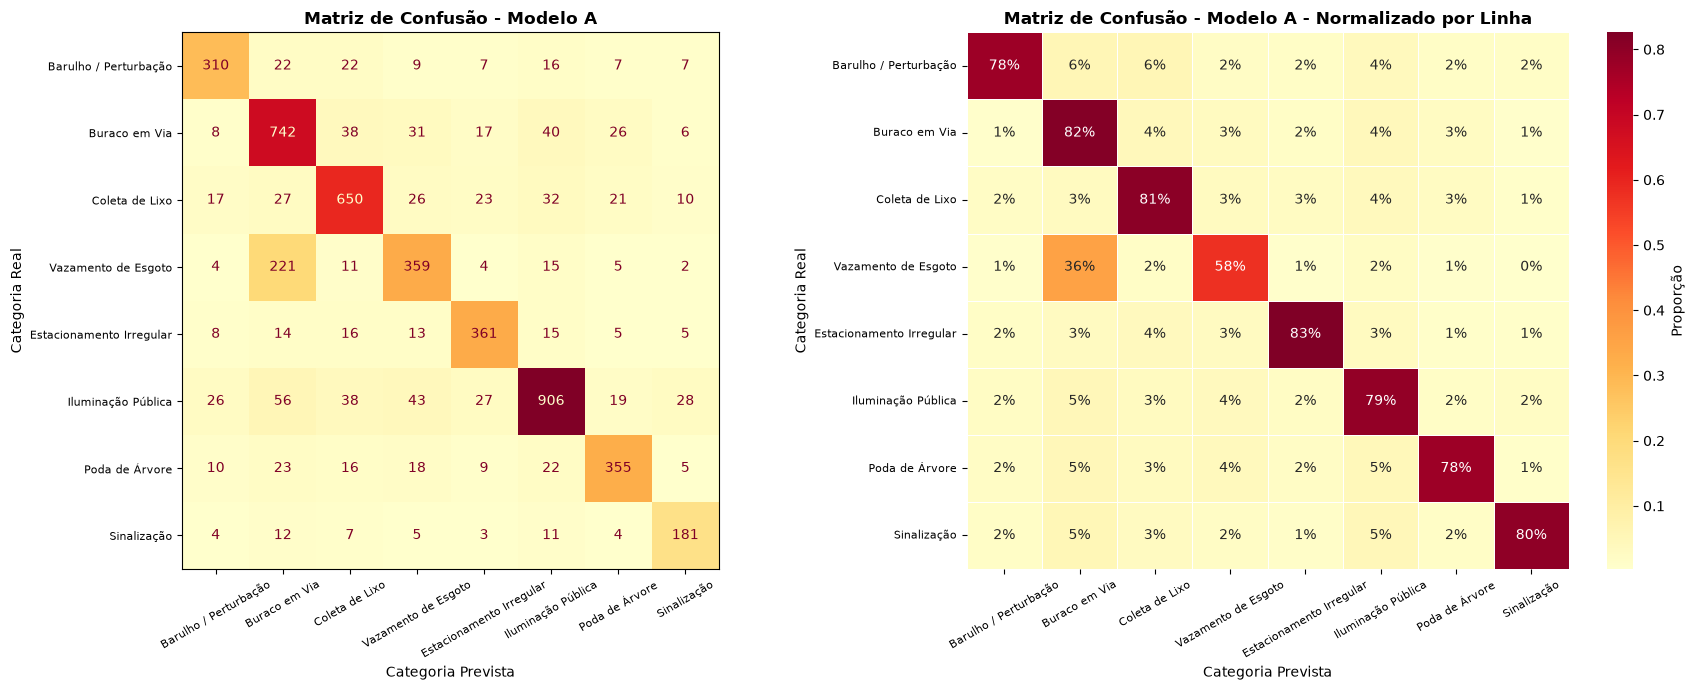

In [6]:
cm = confusion_matrix(y_true, y_pred, labels=classes)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Matriz absoluta
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[cat_map.get(c, c) for c in classes])
disp.plot(ax=axes[0], cmap='YlOrRd', values_format='d', colorbar=False)
axes[0].set_title('Matriz de Confusão - Modelo A', fontweight='bold')
axes[0].set_ylabel('Categoria Real')
axes[0].set_xlabel('Categoria Prevista')
axes[0].tick_params(axis='x', rotation=30, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# Matriz normalizada (por linha = recall)
sns.heatmap(cm_norm, annot=True, fmt='.0%', cmap='YlOrRd',
            xticklabels=[cat_map.get(c, c) for c in classes],
            yticklabels=[cat_map.get(c, c) for c in classes],
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'Proporção'})
axes[1].set_title('Matriz de Confusão - Modelo A - Normalizado por Linha', fontweight='bold')
axes[1].set_ylabel('Categoria Real')
axes[1].set_xlabel('Categoria Prevista')
axes[1].tick_params(axis='x', rotation=30, labelsize=8)
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'matriz_confusao_A.png', bbox_inches='tight', dpi=150)
plt.show()

In [7]:
df['erro'] = df['categoria_real'] != df['pred_modelo_a']

print('Taxa de erro por categoria:')
error_by_cat = df.groupby('categoria_real')['erro'].agg(['mean', 'count', 'sum'])
error_by_cat.columns = ['Taxa Erro', 'Total', 'Erros']
error_by_cat.index = [cat_map.get(c, c) for c in error_by_cat.index]
error_by_cat = error_by_cat.sort_values('Taxa Erro', ascending=False)
print(error_by_cat.to_string())
print()

print(f'Total de erros: {df["erro"].sum()} / {len(df)} ({df["erro"].mean()*100:.1f}%)')

Taxa de erro por categoria:
                          Taxa Erro  Total  Erros
Vazamento de Esgoto        0.421900    621    262
Barulho / Perturbação      0.225000    400     90
Poda de Árvore             0.224891    458    103
Iluminação Pública         0.207349   1143    237
Sinalização                0.202643    227     46
Coleta de Lixo             0.193548    806    156
Buraco em Via              0.182819    908    166
Estacionamento Irregular   0.173913    437     76

Total de erros: 1136 / 5000 (22.7%)


In [8]:
top_errors = []
for real in classes:
    for pred in classes:
        if real != pred:
            count = cm[classes.index(real), classes.index(pred)]
            if count > 0:
                top_errors.append({
                    'Real': cat_map.get(real, real),
                    'Previsto': cat_map.get(pred, pred),
                    'Chamados': count
                })

top_errors_df = pd.DataFrame(top_errors).sort_values('Chamados', ascending=False).head(15)
print('Top 15 pares de erro (Real → Previsto):')
top_errors_df

Top 15 pares de erro (Real → Previsto):


,Real,Previsto,Chamados
22,Vazamento de Esgoto,Buraco em Via,221
36,Iluminação Pública,Buraco em Via,56
38,Iluminação Pública,Vazamento de Esgoto,43
11,Buraco em Via,Iluminação Pública,40
37,Iluminação Pública,Coleta de Lixo,38
8,Buraco em Via,Coleta de Lixo,38
18,Coleta de Lixo,Iluminação Pública,32
9,Buraco em Via,Vazamento de Esgoto,31
41,Iluminação Pública,Sinalização,28
39,Iluminação Pública,Estacionamento Irregular,27


Podemos notar inicialmente que em grande maior parte das categorias o desempenho do Modelo A é homogêneo. Possuindo a maior fragilidade na categoria `Vazamento de Esgoto`, que apresenta a maior taxa de erro (42,2%). Essa categoria tem recall consideravelmente pequeno (0,58), indicando que uma parcela relevante dos chamados reais de esgoto não está sendo reconhecida corretamente pelo modelo. Pela matriz de confusão, podemos notar que grande parte desses erros é pela dificuldade do modelo distinguir com a categoria `Buraco em Via` (221 casos). 

Esse resultado é importante do ponto de vista operacional porque chamados de vazamento de esgoto podem exigir resposta rápida e encaminhamento para equipes específicas, dado que entre as categorias ela é uma, se não uma das prioritárias, devido a riscos sanitários, contaminação da água, e proliferação de doenças. Quando o modelo erra essa categoria, há risco de atraso no atendimento, aumento de retrabalho e piora na experiência do cidadão.

Categorias com alto volume, como Iluminação Pública (237 erros), Buraco em Via (166 erros) e Coleta de Lixo (156 erros), também geram muitos erros em termos absolutos, mesmo quando a taxa relativa de erro não é a maior. Portanto, a priorização de melhorias deve considerar tanto a taxa de erro quanto o volume total de chamados afetados.

### 3.2 Falhas por Subgrupos

In [9]:
print('Taxa de erro por canal:')

error_by_canal = df.groupby('canal')['erro'].agg(['mean', 'count', 'sum'])
error_by_canal.columns = ['Taxa Erro', 'Total', 'Erros']

error_by_canal_fmt = error_by_canal.copy()
error_by_canal_fmt['Taxa Erro (%)'] = error_by_canal_fmt['Taxa Erro'] * 100
error_by_canal_fmt = error_by_canal_fmt[['Taxa Erro (%)', 'Total', 'Erros']]

display(error_by_canal_fmt.round({'Taxa Erro (%)': 1}))

print('Taxa de erro por bairro - top 10 por número de erros:')

error_by_bairro = df.groupby('bairro')['erro'].agg(['mean', 'count', 'sum'])
error_by_bairro.columns = ['Taxa Erro', 'Total', 'Erros']

top_error_bairros = error_by_bairro.sort_values('Erros', ascending=False).head(10).copy()
top_error_bairros['Taxa Erro (%)'] = top_error_bairros['Taxa Erro'] * 100
top_error_bairros = top_error_bairros[['Taxa Erro (%)', 'Total', 'Erros']]

display(top_error_bairros.round({'Taxa Erro (%)': 1}))

Taxa de erro por canal:


,Taxa Erro (%),Total,Erros
canal,,,
app_1746,23.6,2408,568
portal_web,22.0,868,191
telefone_1746,21.9,1724,377


Taxa de erro por bairro - top 10 por número de erros:


,Taxa Erro (%),Total,Erros
bairro,,,
Campo Grande,21.8,533,116
Jacarepaguá,21.4,467,100
Bangu,21.1,435,92
Barra da Tijuca,22.8,403,92
Tijuca,23.3,387,90
Santa Cruz,24.3,358,87
Madureira,25.0,340,85
Copacabana,21.1,350,74
Centro,23.9,305,73


As taxas de erro por canal, e bairro são próximas entre si, sugerindo que o canal de entrada e o bairro, não são fatores associado às falhas do Modelo A.

In [10]:
print('Taxa de erro por faixa de confiança do modelo A:')

bins = [0, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0]
labels = ['<70%', '70-80%', '80-85%', '85-90%', '90-95%', '>95%']

df['conf_faixa'] = pd.cut(
    df['conf_modelo_a'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

error_by_conf = df.groupby('conf_faixa', observed=True)['erro'].agg(['mean', 'count', 'sum'])
error_by_conf.columns = ['Taxa Erro', 'Total', 'Erros']

error_by_conf_fmt = error_by_conf.copy()
error_by_conf_fmt['Taxa Erro (%)'] = error_by_conf_fmt['Taxa Erro'] * 100
error_by_conf_fmt = error_by_conf_fmt[['Taxa Erro (%)', 'Total', 'Erros']]

display(error_by_conf_fmt.round({'Taxa Erro (%)': 1}))

high_conf_erros = df[(df['conf_modelo_a'] >= 0.95) & (df['erro'])]
print(
    f'Erros com confiança >= 95%: {len(high_conf_erros)} '
    f'({len(high_conf_erros) / df["erro"].sum() * 100:.1f}% dos erros totais)'
)

if len(high_conf_erros) > 0:
    print('Distribuição dos erros de alta confiança por categoria real:')
    hc_err_cat = high_conf_erros['categoria_real'].value_counts()
    hc_err_cat.index = [cat_map.get(c, c) for c in hc_err_cat.index]
    print(hc_err_cat.to_string())

Taxa de erro por faixa de confiança do modelo A:


,Taxa Erro (%),Total,Erros
conf_faixa,,,
<70%,12.5,8,1
70-80%,20.9,134,28
80-85%,26.4,318,84
85-90%,21.3,928,198
90-95%,22.9,1864,426
>95%,22.8,1748,399


Erros com confiança >= 95%: 415 (36.5% dos erros totais)
Distribuição dos erros de alta confiança por categoria real:
Vazamento de Esgoto         92
Iluminação Pública          89
Coleta de Lixo              62
Buraco em Via               59
Poda de Árvore              43
Barulho / Perturbação       25
Sinalização                 24
Estacionamento Irregular    21


Em um sistema de triagem automática, é comum usar a confiança (ou métrica similar) como critério para decidir se um chamado pode ser encaminhado automaticamente ou se precisa de revisão humana. Dessa maneira, o modelo A é problemático nesse sentido, pois quando declarada com alta confiança (95%), o modelo erra 36,5% de todos os erros (415 chamados). E isso se mantém constante (entre cerca de 21% e 26%) em todas as faixas de confiança com volume relevante. 

Esse resultado sugere que o Modelo A pode estar mal calibrado ou excessivamente confiante em parte das suas predições. Portanto, qualquer uso operacional baseado em limiar de confiança deve ser acompanhado de monitoramento contínuo e, se possível, calibração das probabilidades antes de decisões totalmente automáticas.